In [15]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [16]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
X_test = joblib.load("../data/processed/X_test.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

model = joblib.load("../models/random_forest.pkl")

risk_probability = model.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    "Default_Probability": risk_probability,
    "Actual_Default": y_test.values
})

display(risk_df.head())

,Default_Probability,Actual_Default
0,0.309232,0
1,0.378482,0
2,0.377374,0
3,0.391734,1
4,0.128032,0


In [18]:
def risk_category(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [19]:
risk_df["Risk_Category"] = (
    risk_df["Default_Probability"]
    .apply(risk_category)
)

print(risk_df["Risk_Category"].value_counts())

Risk_Category
Medium Risk    2799
Low Risk       2064
High Risk      1137
Name: count, dtype: int64


In [20]:
risk_summary = (
    risk_df
    .groupby("Risk_Category")
    .agg(
        Customers=("Risk_Category", "size"),
        Average_Default_Probability=(
            "Default_Probability",
            "mean"
        ),
        Actual_Default_Rate=(
            "Actual_Default",
            "mean"
        )
    )
)

risk_summary["Actual_Default_Rate"] *= 100

risk_summary = risk_summary.reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

display(risk_summary)

,Customers,Average_Default_Probability,Actual_Default_Rate
Risk_Category,,,
Low Risk,2064,0.229689,7.800388
Medium Risk,2799,0.408286,18.399428
High Risk,1137,0.778819,57.255937


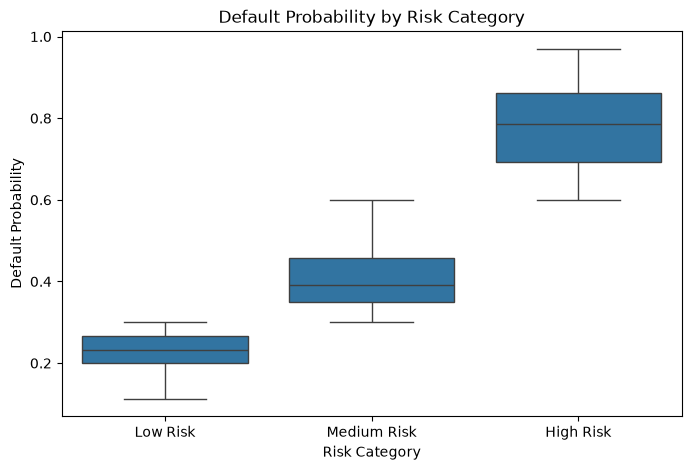

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=risk_df,
    x="Risk_Category",
    y="Default_Probability",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.xlabel("Risk Category")
plt.ylabel("Default Probability")
plt.title("Default Probability by Risk Category")

plt.show()

In [22]:
risk_df.to_csv(
    "../data/processed/risk_predictions.csv",
    index=False
)

print("Risk predictions saved successfully.")

Risk predictions saved successfully.
